<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-7---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Programacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1

# Sección 1:  SGD y variantes en regresión logística

## Descripción del problema
Clasificar imágenes de sangre (BloodMNIST) en los 8 tipos que existen.

## Metodología
### 1. SGD y alguna de sus variantes
-	Preprocesar imágenes (normalización, reshape).
-	Implementar regresión logística con pérdida cross entropy.
-	Entrenar con SGD clásico
- Entrenar la variante XXX (SGD + momentum, AdaGrad,
RMSProp, Adam).

# Programación

*   Instalación de Librerías
*   EDA
*   Regresión logística




In [ ]:
# Librerías necesarias para el código
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
!pip install medmnist
from medmnist import BloodMNIST
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

train_dataset = BloodMNIST(split='train', download=True)
test_dataset = BloodMNIST(split='test', download=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.1 MB/s eta 0:00:00


 37%|███▋      | 13.3M/35.5M [00:20<00:31, 714kB/s]

In [ ]:
# Tamaño o número de registros de la base de imágenes
print(len(dataset))

# Tamaño
images = dataset.imgs
labels = dataset.labels

print("Shape imágenes:", images.shape)
print("Shape etiquetas:", labels.shape)
print("Clases únicas:", np.unique(labels))

# Visualizar algunas imágenes
fig, axes = plt.subplots(1, 5, figsize=(15,3))

for i in range(5):
    imagen, etiqueta = dataset[i]
    axes[i].imshow(imagen)
    axes[i].set_title(f"Clase: {etiqueta}")
    axes[i].axis("off")

plt.show()

In [ ]:
# Calcular frecuencia por clase
freq = pd.Series(labels).value_counts().sort_index()

print("Frecuencia de imágenes por etiqueta:")
print(freq)

# Visualizar en gráfico de barras
import matplotlib.pyplot as plt

In [ ]:
# Extraer imágenes (X) y etiquetas (y)
X_train = train_dataset.imgs
y_train = train_dataset.labels.squeeze()
X_test = test_dataset.imgs
y_test = test_dataset.labels.squeeze()

# Transformación programática: Aplanar las imágenes de (N, 28, 28, 3) a (N, 2352)
# Usar -1 infiere automáticamente la dimensión restante, adaptándose a cualquier conjunto.
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Estandarización de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# Codificación One-Hot para las etiquetas (preparación para Cross Entropy)
num_classes = len(np.unique(y_train))
y_train_onehot = np.eye(num_classes)[y_train]

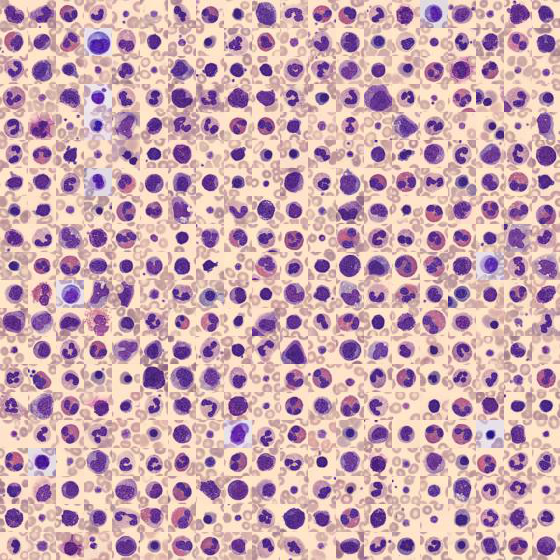

In [ ]:
display(train_dataset.montage(length=20))

In [ ]:
class RegresionLogisticaMomentum:
    def __init__(self, learning_rate=0.01, momentum=0.9, epochs=100, batch_size=64):
        self.lr = learning_rate
        self.gamma = momentum  # Coeficiente de inercia
        self.epochs = epochs
        self.batch_size = batch_size
        self.W = None
        self.b = None
        self.loss_history = []

    def _softmax(self, z):
        # Restar el máximo por estabilidad numérica (evitar overflow)
        z_safe = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_safe)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _compute_loss(self, y_true, y_pred):
        # Añadir un pequeño epsilon para evitar log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        # Cross entropy
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = y.shape[1]  # Asumiendo que y viene en formato One-Hot

        # Inicialización programática de parámetros y velocidades
        self.W = np.random.randn(n_features, n_classes) * 0.01
        self.b = np.zeros((1, n_classes))

        v_W = np.zeros_like(self.W)
        v_b = np.zeros_like(self.b)

        for epoch in range(self.epochs):
            # Mezclar los datos en cada época para la naturaleza estocástica
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            num_batches = 0

            # Iterar sobre mini-lotes
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                # 1. Forward pass (Puntajes y Activación)
                linear_output = np.dot(X_batch, self.W) + self.b
                y_pred = self._softmax(linear_output)

                # 2. Calcular gradientes
                # El gradiente de la cross entropy con softmax se simplifica a (y_pred - y_true)
                dW = np.dot(X_batch.T, (y_pred - y_batch)) / self.batch_size
                db = np.sum(y_pred - y_batch, axis=0, keepdims=True) / self.batch_size

                # 3. Actualización con Momentum
                v_W = self.gamma * v_W + self.lr * dW
                v_b = self.gamma * v_b + self.lr * db

                self.W -= v_W
                self.b -= v_b

                epoch_loss += self._compute_loss(y_batch, y_pred)
                num_batches += 1

            # Guardar la pérdida promedio de la época
            self.loss_history.append(epoch_loss / num_batches)

            # Imprimir progreso cada 10 épocas
            if epoch % 10 == 0 or epoch == self.epochs - 1:
                print(f"Época {epoch}/{self.epochs} - Loss: {self.loss_history[-1]:.4f}")

    def predict(self, X):
        linear_output = np.dot(X, self.W) + self.b
        y_pred = self._softmax(linear_output)
        return np.argmax(y_pred, axis=1)

In [ ]:
# Instanciar el modelo con momentum
modelo_momentum = RegresionLogisticaMomentum(learning_rate=0.01, momentum=0.9, epochs=50, batch_size=128)

# Entrenar (usando las variables escaladas y codificadas que generamos previamente)
modelo_momentum.fit(X_train_scaled, y_train_onehot)

# Predecir sobre el conjunto de prueba
predicciones = modelo_momentum.predict(X_test_scaled)

Época 0/50 - Loss: 0.9735
Época 10/50 - Loss: 0.4540
Época 20/50 - Loss: 0.3780
Época 30/50 - Loss: 0.3504
Época 40/50 - Loss: 0.3431
Época 49/50 - Loss: 0.3150


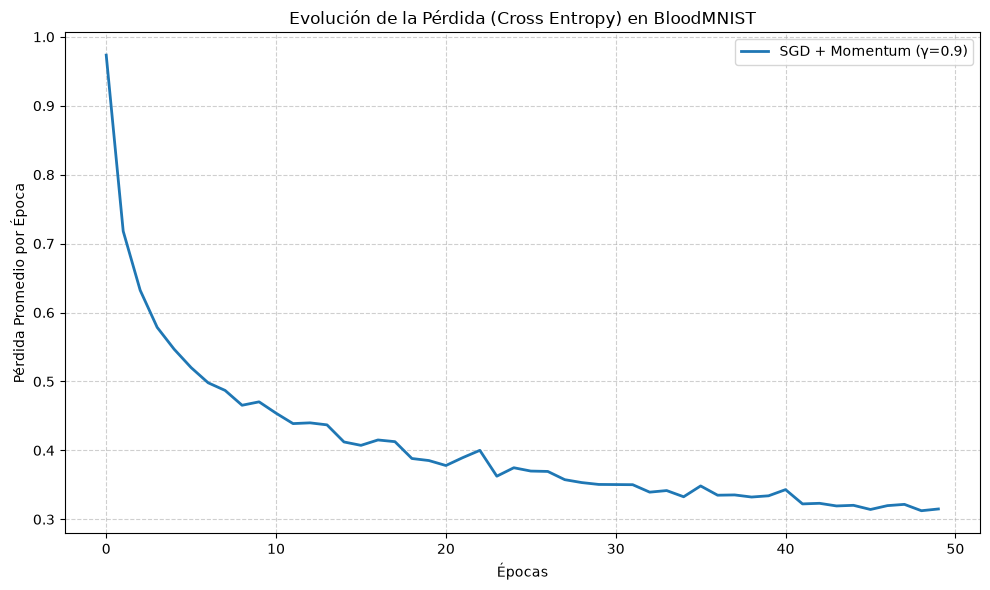

Exactitud (Accuracy) en el conjunto de prueba: 79.13%

Reporte de Clasificación (Desempeño por clase):
              precision    recall  f1-score   support

           0     0.6332    0.5943    0.6131       244
           1     0.9074    0.9423    0.9245       624
           2     0.8145    0.8328    0.8235       311
           3     0.5900    0.5889    0.5895       579
           4     0.7714    0.7778    0.7746       243
           5     0.5863    0.6338    0.6091       284
           6     0.8675    0.8063    0.8358       666
           7     0.9811    0.9957    0.9884       470

    accuracy                         0.7913      3421
   macro avg     0.7689    0.7715    0.7698      3421
weighted avg     0.7917    0.7913    0.7911      3421



In [ ]:
# 1. Gráfica de evolución de la función de pérdida
plt.figure(figsize=(10, 6))
plt.plot(modelo_momentum.loss_history, label='SGD + Momentum (γ=0.9)', color='#1f77b4', linewidth=2)
plt.title('Evolución de la Pérdida (Cross Entropy) en BloodMNIST')
plt.xlabel('Épocas')
plt.ylabel('Pérdida Promedio por Época')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Evaluación cuantitativa y métricas en formato tabular
exactitud = accuracy_score(y_test, predicciones)
print(f"Exactitud (Accuracy) en el conjunto de prueba: {exactitud * 100:.2f}%\n")

# Generar una tabla de métricas (Precisión, Recall, F1-Score) para las 8 clases de células
reporte = classification_report(y_test, predicciones, digits=4)
print("Reporte de Clasificación (Desempeño por clase):")
print(reporte)

# Resultados

En la curva de pérdida y exactitud se aprecia que...

# Conclusiones

Lorem ipsum

## 2. SGD en Scikit-learn

# Descripción del problema

# Metodología

Revisión documental: Realizar una revisión de la documentación de scikit-learn sobre el uso de descenso de gradiente estocástico, tanto para regresión como para clasificación. En particular, deberán revisar las clases SGDRegressor y SGDClassifier.



El objetivo del proyecto es explicar cómo se implementa SGD en scikit-learn, qué funciones de pérdida permite usar, qué parámetros son importantes y cómo se relaciona su funcionamiento con lo estudiado en clase. Hacer un ejemplito de uso con datos reales:


1. Revisar la documentación oficial de:
SGDRegressor y SGDClassifier.
2. Explicar el papel de los siguientes elementos:
función de pérdida;
tasa de aprendizaje;
regularización;
número de épocas;
escalamiento de variables;
criterio de parada.
3. Aplicar SGDRegressor a un problema de regresión con una base de datos real. Una opción recomendada es la base California Housing, disponible en scikit-learn, o bien, aplicar SGDClassifier a un problema de clasificación con una base de datos real. Una opción recomendada es la base Breast Cancer Wisconsin, también disponible en scikit-learn.
4. Comparar los resultados con un método de referencia, por ejemplo:
regresión lineal ordinaria para el problema de regresión;
regresión logística para el problema de clasificación.

## 2
- **Función de pérdida (loss):** Es la métrica matemática que el algoritmo intenta minimizar durante el entrenamiento. En SGDClassifier, usar loss='log_loss' implementa regresión logística, mientras que loss='hinge' implementa una Máquina de Vectores de Soporte (SVM). En SGDRegressor, loss='squared_error' minimiza los mínimos cuadrados ordinarios.  
- **Tasa de aprendizaje (learning_rate):** Controla el tamaño del paso que da el optimizador en cada iteración para actualizar los pesos. En scikit-learn, puede ser constante, óptima (disminuye gradualmente basada en una heurística) o adaptativa (disminuye solo cuando el error deja de mejorar).
- **Regularización (penalty):** Es un término de penalización que se añade a la función de pérdida para evitar el sobreajuste (overfitting). Scikit-learn permite penalizaciones L2 (Ridge, encoge los pesos de manera uniforme), L1 (Lasso, fuerza algunos pesos a cero para selección de variables) o Elastic Net (una combinación de ambas).
- **Número de épocas (max_iter):** Representa el número máximo de veces que el algoritmo iterará sobre el conjunto de datos de entrenamiento completo. Si se alcanza este número, el algoritmo se detiene, incluso si no ha convergido idealmente.
- **Escalamiento de variables:** SGD es altamente sensible a la escala de las características (features). Si una variable tiene un rango de 0 a 1000 y otra de 0 a 1, el gradiente estará dominado por la primera, provocando oscilaciones severas. Por ello, es imperativo usar un escalador (como StandardScaler) antes de entrenar.
- **Criterio de parada (tol / early_stopping):** Es la condición lógica que le indica al algoritmo cuándo detenerse antes de alcanzar el número máximo de épocas. Generalmente, se detiene si la pérdida no mejora al menos una cantidad determinada (tol) durante un número específico de épocas continuas.


In [ ]:
# Programación

In [ ]:
print("Hello World")

Hello World


# Resultados
Se observa que...

# Conclusiones
Lorem ipsum...

### 3. SGD y sus variantes en redes neuronales, escoger uno de los siguientes:
#### 3.1. SGD y sus variantes para clasificación
Usar redes neuronales para un problema de clasificación de imágenes. El
objetivo es comparar el comportamiento de diferentes optimizadores en el
entrenamiento de una misma arquitectura de red neuronal.

Actividades
1. Construir una red neuronal convolucional sencilla para clasificación de
imágenes.
2. Mantener fija la arquitectura de la red y cambiar únicamente el opti-
mizador.
3. Comparar, según la paquetería utilizada, algunos de los siguientes mé-
todos:
SGD clásico;
SGD con momentum;
SGD con momentum de Nesterov;
AdaGrad;
RMSProp;
Adam;
AdamW, si está disponible.
4. Reportar la evolución de la función de pérdida durante el entrenamien-
to.
5. Reportar la exactitud en entrenamiento y validación.
6. Analizar si los optimizadores adaptativos convergen más rápido o si logran mejor desempeño final.

Preguntas a responder
1. ¿Qué optimizador reduce más rápido la función de pérdida?
2. ¿El optimizador con mejor desempeño en entrenamiento también es el
mejor en validación?
3. ¿Qué método parece más sensible a la elección de la tasa de aprendi-
zaje?

#### 3.2. SGD y sus variantes en redes neuronales para regresión
Usar redes neuronales para resolver un problema de regresión con datos reales. El objetivo es comparar el comportamiento de diferentes optimizadores en el entrenamiento de una red neuronal para regresión.

Actividades
1. Explorar la base de datos seleccionada.
2. Separar los datos en entrenamiento, validación y prueba.
3. Estandarizar las variables explicativas.
4. Construir una red neuronal multicapa sencilla.
5. Entrenar la misma arquitectura usando diferentes optimizadores:
SGD;
SGD con momentum;
AdaGrad;
RMSProp;
Adam;
AdamW, si está disponible.
6. Comparar los métodos usando métricas de regresión como:
MSE;
MAE;
RMSE;
R2.
7. Graficar la pérdida de entrenamiento y validación para cada optimiza-
dor.

Preguntas
1. ¿Qué optimizador converge más rápido?
2. ¿Qué optimizador logra menor error de validación?
3. ¿Hay evidencia de sobreajuste?
4. ¿Cómo afecta la tasa de aprendizaje al desempeño?